## Rescale Astrocyte Maps for the Spatial Simulation Grid

Rescale segmented astrocyte maps based on the desired spatial grid resolution and target soma area.

#### Define Segmentation Visualization Utilities

In [13]:
# ========================================
# Rescale Images using Spatial Grid Step
# ========================================

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

def visualize_and_check_regions(segmentation_file):
    # Load the segmented astrocyte
    segmented_data = np.load(segmentation_file)

    # Get unique labels and their counts
    unique_values, counts = np.unique(segmented_data, return_counts=True)
    label_counts = dict(zip(unique_values, counts))
    print(f"Initial Unique Values in segmented_data: {label_counts}")

    # Sort labels by pixel count in ascending order
    sorted_labels = sorted(label_counts, key=label_counts.get)
    # Assign labels dynamically
    soma_label = sorted_labels[0]
    thick_branch_label = sorted_labels[1]
    thin_process_label = sorted_labels[2]
    background_label = sorted_labels[3]

    soma_mask = segmented_data == soma_label
    thick_branch_mask = segmented_data == thick_branch_label
    thin_process_mask = segmented_data == thin_process_label
    background_mask = segmented_data == background_label

    # Compute pixel counts
    soma_pixels = np.sum(soma_mask)
    thick_pixels = np.sum(thick_branch_mask)
    thin_pixels = np.sum(thin_process_mask)
    background_pixels = np.sum(background_mask)

    # Print pixel counts
    print(f"\nPixel Counts for {segmentation_file}:")
    print(f"  Soma: {soma_pixels} pixels")
    print(f"  Thick Branches: {thick_pixels} pixels")
    print(f"  Thin Processes: {thin_pixels} pixels")
    print(f"  Background: {background_pixels} pixels")

    # ========================================
    # Plot Each Region Separately
    # ========================================
    fig, axs = plt.subplots(1, 4, figsize=(20, 5))

    # Soma
    axs[0].imshow(soma_mask.astype(int), cmap="Reds")
    axs[0].set_title(f"Soma ({soma_pixels} pixels)")
    axs[0].axis("off")

    # Thick branches
    axs[1].imshow(thick_branch_mask.astype(int), cmap="Blues")
    axs[1].set_title(f"Thick Branches ({thick_pixels} pixels)")
    axs[1].axis("off")

    # Thin processes
    axs[2].imshow(thin_process_mask.astype(int), cmap="Greens")
    axs[2].set_title(f"Thin Processes ({thin_pixels} pixels)")
    axs[2].axis("off")

    # Background
    axs[3].imshow(background_mask.astype(int), cmap="gray")
    axs[3].set_title(f"Background ({background_pixels} pixels)")
    axs[3].axis("off")

    plt.tight_layout()
    plt.show()

def visualize_masks(title, **masks):
    """
    Visualizes multiple binary masks in a single figure.

    Parameters:
    title (str): The main title of the figure.
    **masks: Key-value pairs where key is the mask name (str) and value is the binary mask (numpy array).
    """
    num_masks = len(masks)
    fig, axs = plt.subplots(1, num_masks, figsize=(5 * num_masks, 5))

    if num_masks == 1:
        axs = [axs]  # Ensure axs is iterable for single mask

    for ax, (name, mask) in zip(axs, masks.items()):
        ax.imshow(mask, cmap="gray")
        ax.set_title(f"{name} ({np.sum(mask)} pixels)")
        ax.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

    # Print pixel counts for debugging
    print(f"\n🔍 Debugging: {title}")
    for name, mask in masks.items():
        print(f"  {name}: {np.sum(mask)} pixels")

def visualize_connectivity_graph(connectivity_pixel):
    """
    Visualizes the updated connectivity graph for astrocyte regions.
    
    Parameters:
        connectivity_pixel (dict): A dictionary containing connectivity percentages between regions.
    """
    # Define the graph
    connectivity_graph_pixel = nx.Graph()
    
    # Add nodes (Soma, Thick Branches, Thin Processes)
    connectivity_graph_pixel.add_nodes_from(["Soma", "Thick Branches", "Thin Processes"])
    
    # Define the connectivity edges and weights
    connectivity_edges_pixel = {
        ("Soma", "Thick Branches"): connectivity_pixel["Soma ↔ Thick"],
        ("Soma", "Thin Processes"): connectivity_pixel["Soma ↔ Thin"],
        ("Thick Branches", "Thin Processes"): connectivity_pixel["Thick ↔ Thin"],
        ("Thin Processes", "Thin Processes"): connectivity_pixel["Thin ↔ Thin"],
    }
    
    # Add edges with weights (percentages)
    for edge, weight in connectivity_edges_pixel.items():
        connectivity_graph_pixel.add_edge(edge[0], edge[1], weight=weight)
    
    # Define a fixed triangular layout
    pos = {
        "Soma": (0, 1),
        "Thick Branches": (-1, 0),
        "Thin Processes": (1, 0),
    }
    
    # Extract edge weights for labeling
    weights = nx.get_edge_attributes(connectivity_graph_pixel, "weight")
    
    # Visualize the triangular graph
    plt.figure(figsize=(6, 5))
    
    # Draw the graph with nodes
    nx.draw(
        connectivity_graph_pixel,
        pos,
        with_labels=True,
        node_size=2000,
        node_color="lightblue",
        font_size=8,
        font_weight="bold",
    )
    
    # Draw edges with connectivity labels
    nx.draw_networkx_edge_labels(
        connectivity_graph_pixel,
        pos,
        edge_labels={k: f"{v:.2f}%" for k, v in weights.items()},
        font_size=10,
    )
    
    plt.title("Astrocyte Region Connectivity")
    plt.show()
    
# =================================================================================
# Compute Pixel-Level Connectivity (Including Self-Connectivity)
# =================================================================================
def compute_pixel_connectivity(mask1, mask2):
    """Compute percentage of mask1 pixels that are directly adjacent to mask2 pixels."""
    connected_pixels = 0
    total_pixels = np.sum(mask1)
    height, width = mask1.shape  # Get shape of the mask

    # Define search radius
    radius = 3  

    for i in range(height):  # Iterate safely over rows
        for j in range(width):  # Iterate safely over columns
            if mask1[i, j]:  # If this pixel belongs to region 1
                # Ensure indices stay within valid bounds
                i_min = max(0, i - radius)
                i_max = min(height, i + radius + 1)
                j_min = max(0, j - radius)
                j_max = min(width, j + radius + 1)

                neighbors = mask2[i_min:i_max, j_min:j_max].ravel()  # Extract valid neighbors
                if np.any(neighbors):  # Check if any neighbor belongs to region 2
                    connected_pixels += 1

    return (connected_pixels / total_pixels) * 100 if total_pixels > 0 else 0


#### Rescale Astrocyte Maps to a Target Soma Size


Processing: Healthy_astro_1_stitched.npy
  Original Soma Pixels: 397733
  Target Soma Pixels: 350
  Computed Adjusted Scale Factor: 0.030

Scaling factors saved to scaling_factors.json
  Rescaled Soma Pixel Count: 351
  New dx After Rescaling: 0.546 μm/pixel
  Saved Rescaled Astrocyte to: Step_3_Rescaled_Healthy_NPYs/Healthy_astro_1_stitched_rescaled.npy


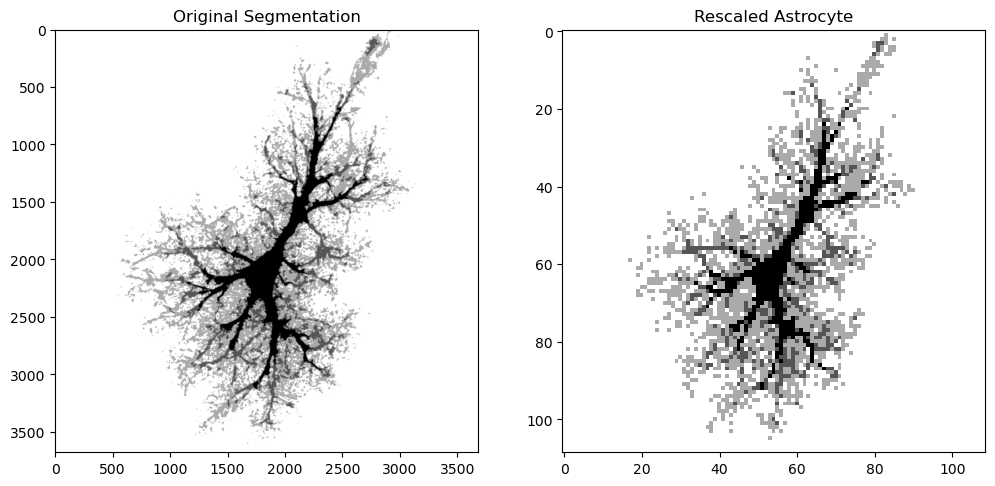

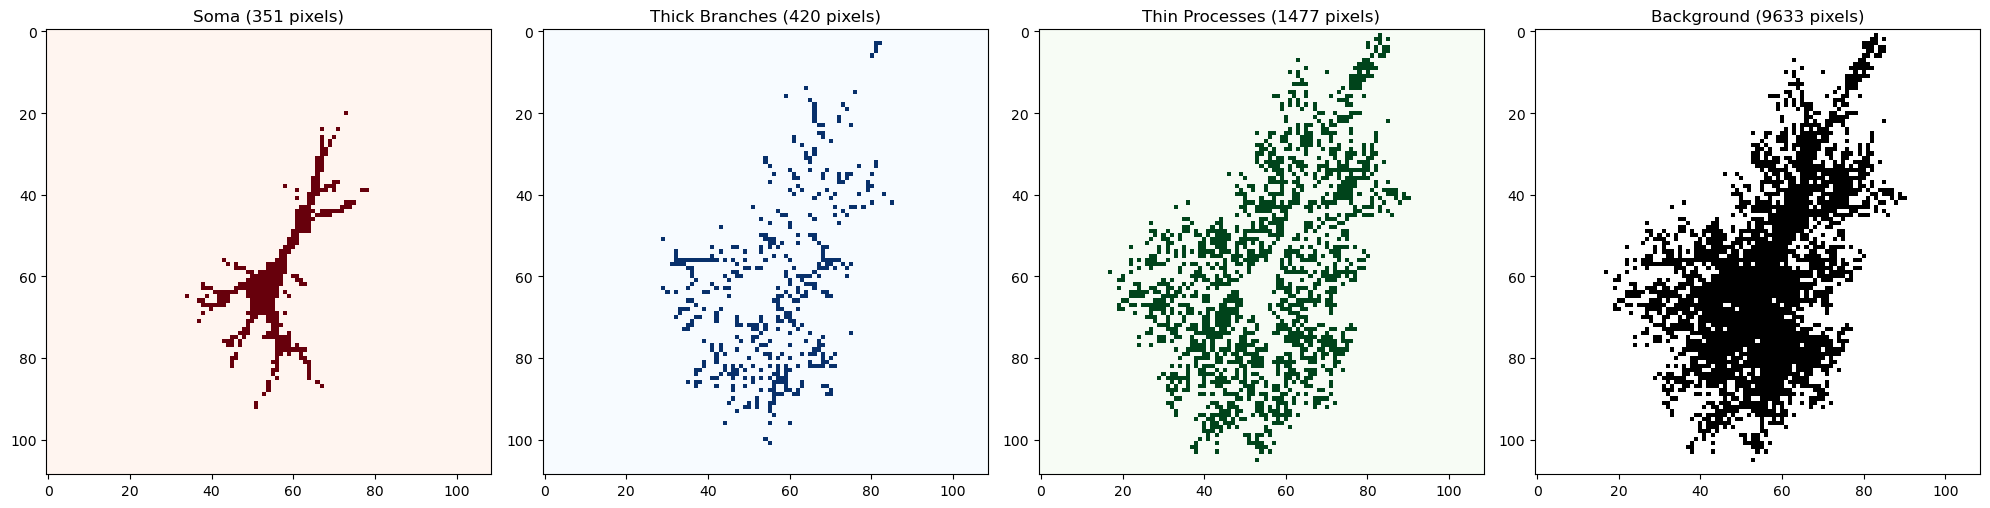

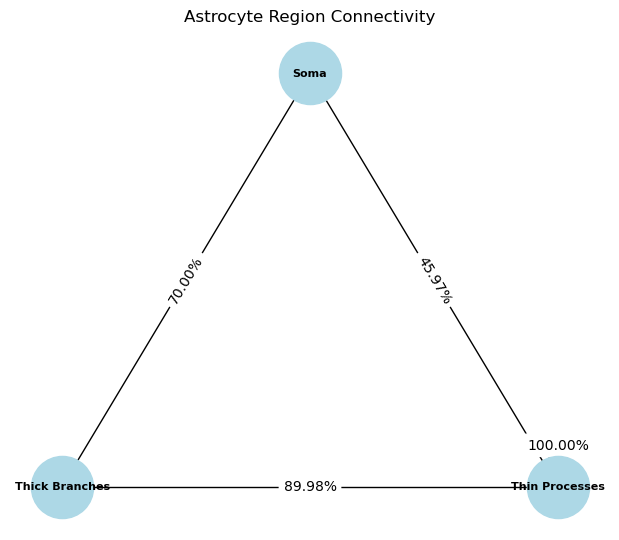

In [14]:
import numpy as np
import os
import matplotlib.pyplot as plt
from skimage.transform import rescale
import json

# ==========================================
# Set Directories and Target Soma Size
# ==========================================
input_dir = "Step_1_Cropped_Healthy_NPYs"  # Directory with astrocyte .npy files
output_dir = "Step_3_Rescaled_Healthy_NPYs"  # Directory to save rescaled files
scaling_factors_file = "scaling_factors.json"  # JSON file to store scaling factors
os.makedirs(output_dir, exist_ok=True)

target_soma_pixels = 350  # Target pixel count for soma region
scaling_factors = {}

# ==========================================
# Loop Through Each Astrocyte
# ==========================================
for filename in sorted(os.listdir(input_dir)):
    if filename.endswith(".npy"):
        file_path = os.path.join(input_dir, filename)
        segmented_data = np.load(file_path)
        astrocyte_id = filename.split("_")[2]  # Extracts the ID (e.g., "10", "4", "5")

        # ==========================================
        # Ensure Fixed Label Assignments
        # ==========================================
        soma_label = 0
        thick_branch_label = 1
        thin_process_label = 2
        background_label = 3

        # Create masks using **fixed labels**
        soma_mask = segmented_data == soma_label
        thick_branch_mask = segmented_data == thick_branch_label
        thin_process_mask = segmented_data == thin_process_label
        background_mask = segmented_data == background_label

        # Compute current soma size
        current_soma_pixels = np.sum(soma_mask)

        # ==========================================
        # Compute Scale Factor for Each Astrocyte
        # ==========================================
        dx_original = 0.0162  # Original pixel size in μm
        adjusted_scale_factor = (current_soma_pixels / target_soma_pixels) ** 0.5  # sqrt-based rescale
        target_dx = dx_original * adjusted_scale_factor
        scale_factor = dx_original / target_dx  # Compute new scale factor

        scaling_factors[astrocyte_id] = scale_factor

        print(f"\nProcessing: {filename}")
        print(f"  Original Soma Pixels: {current_soma_pixels}")
        print(f"  Target Soma Pixels: {target_soma_pixels}")
        print(f"  Computed Adjusted Scale Factor: {scale_factor:.3f}")

        with open(scaling_factors_file, "w") as f:
            json.dump(scaling_factors, f, indent=4)

        print(f"\nScaling factors saved to {scaling_factors_file}")

        # ==========================================
        # Rescale the Astrocyte
        # ==========================================
        rescaled_astrocyte = rescale(
            segmented_data, scale_factor, anti_aliasing=False, order=0, preserve_range=True
        ).astype(np.uint8)

        # ==========================================
        # Compute New Pixel Counts
        # ==========================================
        soma_mask_rescaled = rescaled_astrocyte == soma_label
        thick_branch_mask_rescaled = rescaled_astrocyte == thick_branch_label
        thin_process_mask_rescaled = rescaled_astrocyte == thin_process_label
        background_mask_rescaled = rescaled_astrocyte == background_label

        soma_pixels_rescaled = np.sum(soma_mask_rescaled)
        thick_pixels_rescaled = np.sum(thick_branch_mask_rescaled)
        thin_pixels_rescaled = np.sum(thin_process_mask_rescaled)
        background_pixels_rescaled = np.sum(background_mask_rescaled)

        dx_new = dx_original / scale_factor  # Compute new pixel size in μm

        # ==========================================
        # Save Rescaled Image
        # ==========================================
        output_path = os.path.join(output_dir, filename.replace(".npy", "_rescaled.npy"))
        np.save(output_path, rescaled_astrocyte)

        print(f"  Rescaled Soma Pixel Count: {soma_pixels_rescaled}")
        print(f"  New dx After Rescaling: {dx_new:.3f} μm/pixel")
        print(f"  Saved Rescaled Astrocyte to: {output_path}")

        # ==========================================
        # Visualization
        # ==========================================
        fig, axs = plt.subplots(1, 2, figsize=(12, 6))
        axs[0].imshow(segmented_data, cmap="gray")
        axs[0].set_title("Original Segmentation")
        axs[1].imshow(rescaled_astrocyte, cmap="gray")
        axs[1].set_title("Rescaled Astrocyte")
        plt.show()

        fig, axs = plt.subplots(1, 4, figsize=(20, 5))
        axs[0].imshow(soma_mask_rescaled, cmap="Reds")
        axs[0].set_title(f"Soma ({soma_pixels_rescaled} pixels)")
        axs[1].imshow(thick_branch_mask_rescaled, cmap="Blues")
        axs[1].set_title(f"Thick Branches ({thick_pixels_rescaled} pixels)")
        axs[2].imshow(thin_process_mask_rescaled, cmap="Greens")
        axs[2].set_title(f"Thin Processes ({thin_pixels_rescaled} pixels)")
        axs[3].imshow(background_mask_rescaled, cmap="gray")
        axs[3].set_title(f"Background ({background_pixels_rescaled} pixels)")
        plt.tight_layout()
        plt.show()

        # =======================================================================================
        # Compute Pixel-Level Connectivity (Including Self-Connectivity): inter_region_connection
        # =======================================================================================

        def compute_pixel_connectivity(mask1, mask2):
            connected_pixels = 0
            total_pixels = np.sum(mask1)
            height, width = mask1.shape  
            radius = 3  

            for i in range(height): 
                for j in range(width):  
                    if mask1[i, j]:  
                        i_min = max(0, i - radius)
                        i_max = min(height, i + radius + 1)
                        j_min = max(0, j - radius)
                        j_max = min(width, j + radius + 1)

                        neighbors = mask2[i_min:i_max, j_min:j_max].ravel()
                        if np.any(neighbors): 
                            connected_pixels += 1

            return (connected_pixels / total_pixels) * 100 if total_pixels > 0 else 0

        connectivity_pixel = {
            "Soma ↔ Thick": compute_pixel_connectivity(thick_branch_mask_rescaled, soma_mask_rescaled),
            "Thick ↔ Thin": compute_pixel_connectivity(thin_process_mask_rescaled, thick_branch_mask_rescaled),
            "Soma ↔ Thin": compute_pixel_connectivity(thin_process_mask_rescaled, soma_mask_rescaled),
            "Thin ↔ Thin": compute_pixel_connectivity(thin_process_mask_rescaled, thin_process_mask_rescaled),
            "Soma ↔ Soma": compute_pixel_connectivity(soma_mask_rescaled, soma_mask_rescaled),
            "Thick ↔ Thick": compute_pixel_connectivity(thick_branch_mask_rescaled, thick_branch_mask_rescaled),
            "Thin ↔ Thin": compute_pixel_connectivity(thin_process_mask_rescaled, thin_process_mask_rescaled),
        }
        visualize_connectivity_graph(connectivity_pixel)
